In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, NotRequired
from dotenv import load_dotenv

/Users/vikrmaditya/Downloads/Code/LangGraph/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model= 'llama-3.1-8b-instant',
    temperature= 0
)

In [4]:
# define state
class LLMState(TypedDict):

    question: str
    answer: NotRequired[str]

In [5]:
def llm_QA(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following Question: {question}'

    # ask the question to the LLM
    answer =  model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer
    
    return state 


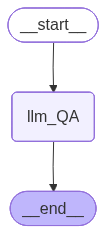

In [6]:
# create graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_QA', llm_QA)

# add edges
graph.add_edge(START, 'llm_QA')
graph.add_edge('llm_QA', END)

# compile
workflow = graph.compile()
workflow

In [7]:
# execute
initial_state = {'question': 'How far is moon from the earth'}

final_state = workflow.invoke(initial_state)

In [8]:
print(final_state)

{'question': 'How far is moon from the earth', 'answer': "The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth.\n\nTo be more precise, the Moon's orbit can be described as follows:\n\n- Perigee (closest point to Earth): approximately 363,300 kilometers (225,300 miles)\n- Apogee (farthest point from Earth): approximately 405,500 kilometers (252,000 miles)\n\nSo, the distance between the Earth and the Moon varies slightly over the course of a month, but the average distance remains around 384,400 kilometers (238,900 miles)."}
